# Jar Growth Intern Assignment - Question 1 (Sales Analysis)

This notebook covers the three parts of Question 1: category-wise sales &
profitability, the Furniture target trend, and the regional (state/city)
breakdown. I've kept the exploration steps in here as well (not just the
final answer) since a couple of the columns in the raw files needed some
cleaning before they could be trusted.

Files used (all three sit in the same folder as this notebook):
- `List_of_Orders.xlsx` - one row per order (date, customer, state, city)
- `Order_Details.xlsx` - one row per order **line item** (category, amount, profit, qty)
- `Sales_target.xlsx` - monthly target per category

Question 2 and Question 3 are answered separately in `Written_Answers.md`
since they don't really involve any computation.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (8, 4.5)


## 1. Loading the raw files

Nothing fancy here, just reading the three sheets in and taking a quick look
at what we're working with before doing any merging.


In [2]:
orders = pd.read_excel('List_of_Orders.xlsx')
details = pd.read_excel('Order_Details.xlsx')
target = pd.read_excel('Sales_target.xlsx')

print('orders  :', orders.shape)
print('details :', details.shape)
print('target  :', target.shape)

orders.head()


orders  : (500, 5)
details : (1500, 6)
target  : (36, 3)


,Order ID,Order Date,CustomerName,State,City
0,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad
1,B-25602,2018-01-04 00:00:00,Pearl,Maharashtra,Pune
2,B-25603,2018-03-04 00:00:00,Jahan,Madhya Pradesh,Bhopal
3,B-25604,2018-03-04 00:00:00,Divsha,Rajasthan,Jaipur
4,B-25605,2018-05-04 00:00:00,Kasheen,West Bengal,Kolkata


In [3]:
details.head()


,Order ID,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,1275,-1148,7,Furniture,Bookcases
1,B-25601,66,-12,5,Clothing,Stole
2,B-25601,8,-2,3,Clothing,Hankerchief
3,B-25601,80,-56,4,Electronics,Electronic Games
4,B-25602,168,-111,2,Electronics,Phones


## 2. A couple of data quality quirks

Before merging anything I like to check dtypes, because Excel exports like
this almost always have at least one column that looks fine but isn't.

Two things showed up here:

1. **`Order Date` in `orders` is a mix of real dates and plain text.** About
   300 of the 500 rows came in as `dd-mm-yyyy` strings (e.g. `13-04-2018`)
   while the rest are already proper `datetime` objects. If you call
   `pd.to_datetime()` on this without `dayfirst=True` pandas will silently
   mis-parse the text ones.
2. **`Month of Order Date` in `target` is worse.** The sheet was clearly
   typed as `Apr-18`, `May-18`, etc., but Excel auto-converted that text into
   a full date, and it picked the *day* field to store the two-digit year
   (18/19) rather than the actual day. So the value that displays as
   `Apr-18` is really stored as day=18, month=Apr, year=<whatever year the
   file happened to be saved in>. The month is trustworthy, the year is not,
   and the "day" is actually the year suffix. Easiest fix is to rebuild the
   label from the month name + that stray day value.


In [4]:
print(orders['Order Date'].map(type).value_counts())
print()

text_dates = orders.loc[orders['Order Date'].map(lambda v: isinstance(v, str))]
print(text_dates['Order Date'].head())

Order Date
<class 'str'>                  307
<class 'datetime.datetime'>    193
Name: count, dtype: int64

13    13-04-2018
14    15-04-2018
15    15-04-2018
16    17-04-2018
17    18-04-2018
Name: Order Date, dtype: object


In [5]:
# dayfirst=True because the text entries are dd-mm-yyyy, not mm-dd-yyyy
orders['Order Date'] = pd.to_datetime(orders['Order Date'], dayfirst=True)
orders['Order Date'].describe()


count                    500
mean     2018-10-19 09:50:24
min      2018-01-04 00:00:00
25%      2018-06-20 06:00:00
50%      2018-10-28 12:00:00
75%      2019-02-05 12:00:00
max      2019-12-03 00:00:00
Name: Order Date, dtype: object

In [6]:
# rebuild a sane month label - see note above on why we can't just use .dt.year.
# keeping the day (real year suffix) and month as their own columns too, since
# the raw date column can't be trusted for *sorting* either - more on that in Part 2
target['year_suffix'] = target['Month of Order Date'].dt.day
target['month_num'] = target['Month of Order Date'].dt.month
month_abbr = target['Month of Order Date'].dt.strftime('%b')
target['month_label'] = month_abbr + '-' + target['year_suffix'].astype(str)
target[['month_label', 'Category', 'Target']].head(3)

,month_label,Category,Target
0,Apr-18,Furniture,10400
1,May-18,Furniture,10500
2,Jun-18,Furniture,10600


## Part 1: Sales and Profitability by Category

Merging `orders` with `details` on `Order ID` gives us one row per line item
with the state/city/date attached. Since `orders` is 1 row per order and
`details` is 1 row per (order, category) line, an inner join is the right
call here - every ID matches on both sides (checked below), so we're not
silently dropping or duplicating anything.


In [7]:
# sanity check before merging - do the order IDs actually line up 1:1?
ids_only_in_details = set(details['Order ID']) - set(orders['Order ID'])
ids_only_in_orders = set(orders['Order ID']) - set(details['Order ID'])
print('order IDs in details but missing from orders:', len(ids_only_in_details))
print('order IDs in orders but missing from details:', len(ids_only_in_orders))

df = orders.merge(details, on='Order ID', how='inner')
print('merged rows:', len(df))
df.head()

order IDs in details but missing from orders: 0
order IDs in orders but missing from details: 0
merged rows: 1500


,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,2018-01-04,Bharat,Gujarat,Ahmedabad,1275,-1148,7,Furniture,Bookcases
1,B-25601,2018-01-04,Bharat,Gujarat,Ahmedabad,66,-12,5,Clothing,Stole
2,B-25601,2018-01-04,Bharat,Gujarat,Ahmedabad,8,-2,3,Clothing,Hankerchief
3,B-25601,2018-01-04,Bharat,Gujarat,Ahmedabad,80,-56,4,Electronics,Electronic Games
4,B-25602,2018-01-04,Pearl,Maharashtra,Pune,168,-111,2,Electronics,Phones


In [8]:
# a plain .mean() on Profit here would be wrong: a single order can (and often does)
# have more than one line item in the *same* category - checked below - so averaging
# the raw line-item rows overstates how many "orders" there are and skews the average.
# Collapsing to one row per (Category, Order ID) first gives the real per-order figure.
dupe_check = details.groupby(['Order ID', 'Category']).size()
dupes = (dupe_check > 1).sum()
n_combos = len(dupe_check)
print(f'order/category combos with >1 line item: {dupes} of {n_combos}')

# profit an order contributes to a given category, averaged across those orders
profit_per_order = (
    df.groupby(['Category', 'Order ID'])['Profit'].sum()
      .groupby('Category').mean()
)

category_summary = df.groupby('Category').agg(
    total_sales=('Amount', 'sum'),
    total_profit=('Profit', 'sum'),
).sort_values('total_sales', ascending=False)

category_summary['distinct_orders'] = df.groupby('Category')['Order ID'].nunique()
category_summary['avg_profit_per_order'] = profit_per_order

sales, profit = category_summary['total_sales'], category_summary['total_profit']
category_summary['profit_margin_pct'] = profit / sales * 100
category_summary

order/category combos with >1 line item: 322 of 783


,total_sales,total_profit,distinct_orders,avg_profit_per_order,profit_margin_pct
Category,,,,,
Electronics,165267,10494,204,51.44,6.35
Clothing,139054,11163,393,28.40,8.03
Furniture,127181,2298,186,12.35,1.81


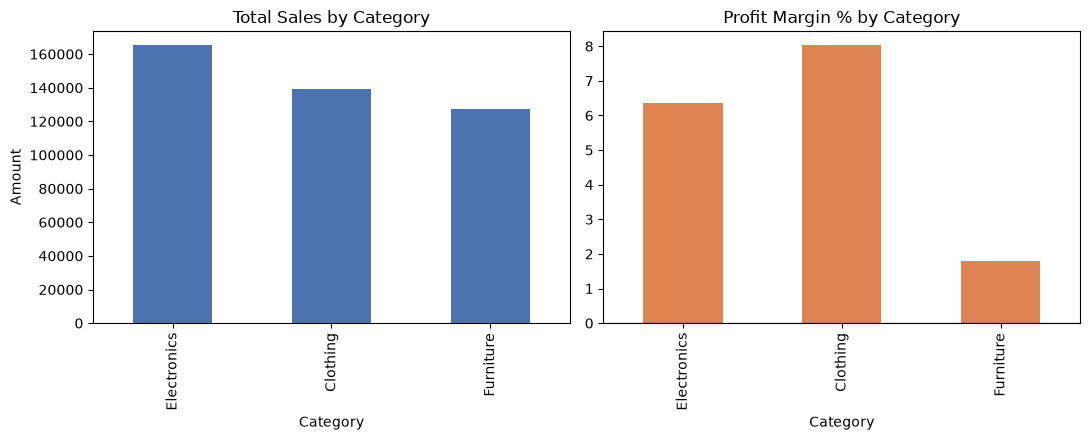

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

category_summary['total_sales'].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Total Sales by Category')
axes[0].set_ylabel('Amount')

category_summary['profit_margin_pct'].plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Profit Margin % by Category')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


Sales alone don't tell the full story here, so let's break each category
down by sub-category to see where the profit is actually being made (or
lost).


In [10]:
sub_summary = df.groupby(['Category', 'Sub-Category']).agg(
    sales=('Amount', 'sum'),
    profit=('Profit', 'sum'),
    orders=('Order ID', 'count'),
).reset_index()
sub_summary['margin_pct'] = sub_summary['profit'] / sub_summary['sales'] * 100

# how many line items in each category actually lost money?
loss_share = (
    df.assign(is_loss=df['Profit'] < 0)
      .groupby('Category')['is_loss']
      .mean() * 100
).rename('pct_line_items_at_a_loss')

sub_summary.sort_values(['Category', 'profit']).merge(
    loss_share, on='Category'
)


,Category,Sub-Category,sales,profit,orders,margin_pct,pct_line_items_at_a_loss
0,Clothing,Kurti,3361,181,47,5.39,29.40
1,Clothing,Skirt,1946,235,64,12.08,29.40
2,Clothing,Leggings,2106,260,53,12.35,29.40
3,Clothing,Saree,53511,352,210,0.66,29.40
4,Clothing,Shirt,7555,1131,69,14.97,29.40
5,Clothing,T-shirt,7382,1500,77,20.32,29.40
6,Clothing,Hankerchief,14608,2098,198,14.36,29.40
7,Clothing,Stole,18546,2559,192,13.80,29.40
8,Clothing,Trousers,30039,2847,39,9.48,29.40
9,Electronics,Electronic Games,39168,-1236,79,-3.16,39.61


### Findings - Part 1

322 of 783 category/order combinations have more than one line item, so the
line-item-level average was overstating the true order count - the numbers
below are the corrected, order-level ones.

**Electronics is the biggest category by revenue (₹1.65L) and by far the
best on a per-order basis** - an order that includes an Electronics item
nets about **₹51 profit on average**, roughly 1.8x Clothing (₹28) and
over 4x Furniture (₹12). That's consistent with it being a higher
ticket-size category (Printers, Phones) where a handful of profitable orders
carry the numbers. The one soft spot inside Electronics is
`Electronic Games`, which is actually loss-making overall (-3.2% margin) and
drags the category average down a bit.

**Clothing has the healthiest margin of the three (~8.0%)** and it gets
there without a single loss-making sub-category - Sarees make up the bulk of
the revenue but at a very thin margin (0.66%), while Stole, Hankerchief and
T-shirt are the ones actually carrying the profit. It's also the highest
reach category by a distance (393 distinct orders touch Clothing vs. 204 for
Electronics and 186 for Furniture), so consistency across a lot of orders
matters more here than any single big win.

**Furniture is the clear underperformer** - lowest total profit (₹2,298),
lowest margin (1.8%), and lowest average profit per order (₹12.35) of the
three. 42% of all Furniture line items lose money, the highest loss-rate of
any category, and it's almost entirely driven by `Tables`, which is sitting
at a **-17.7% margin** on its own. Bookcases and Furnishings are fine on
their own, so this isn't a "the whole category is broken" story - it's a
Tables-specific problem (heavier/bulkier items usually mean higher shipping,
handling, and return costs relative to sale price, which lines up with the
scale of the loss here). Worth flagging that Furniture is also the category
the assignment asks us to look at for target trends in Part 2, which makes
sense given how these numbers look.

## Part 2: Target Achievement Analysis (Furniture)

`Sales_target.xlsx` only has one row per (month, category) - there's no
actual sales figure to compare against here, it's a target-setting sheet, so
this part is about the target trend itself: how much the bar is being raised
month over month and whether that pace looks sensible.


In [11]:
furniture_target = (
    target[target['Category'] == 'Furniture']
    # NOT .sort_values('Month of Order Date') - that column's year is fake and
    # identical across every row (see the note above Part 1), so sorting on it
    # puts Jan/Feb/Mar-19 before Apr-18 instead of after Dec-18. year_suffix
    # (the real year, hiding in what looks like the day field) is what actually
    # separates the two fiscal years.
    .sort_values(['year_suffix', 'month_num'])
    .reset_index(drop=True)
)
furniture_target['mom_change_pct'] = furniture_target['Target'].pct_change() * 100
furniture_target[['month_label', 'Target', 'mom_change_pct']]

,month_label,Target,mom_change_pct
0,Apr-18,10400,NaN
1,May-18,10500,0.96
2,Jun-18,10600,0.95
3,Jul-18,10800,1.89
4,Aug-18,10900,0.93
5,Sep-18,11000,0.92
6,Oct-18,11100,0.91
7,Nov-18,11300,1.80
8,Dec-18,11400,0.88
9,Jan-19,11500,0.88


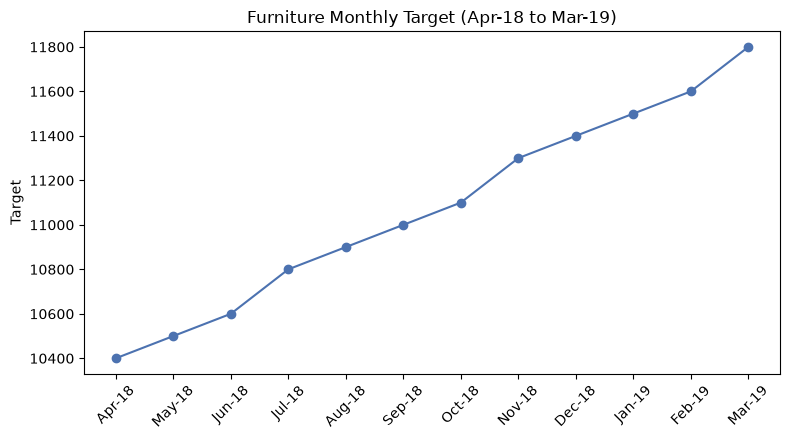

In [12]:
plt.plot(
    furniture_target['month_label'], furniture_target['Target'],
    marker='o', color='#4C72B0',
)
plt.title('Furniture Monthly Target (Apr-18 to Mar-19)')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Findings - Part 2

The Furniture target climbs every single month, so there's no month where
the bar actually drops - but the *pace* isn't constant. Most months step up
by a modest ~0.9%, and then three months (**Jul-18, Nov-18 and Mar-19**) jump
by roughly **1.7-1.9%**, about double the usual increase. That +4 month
spacing (Jul -> Nov -> Mar) is a pretty clean pattern rather than noise, so
it looks like whoever set these targets built in a bigger push once a
quarter on top of the steady monthly growth.

That's a reasonable planning habit in principle, but it's worth pairing
against Part 1's finding that Furniture is already the weakest-margin,
highest-loss-rate category we have. Raising the target steadily assumes the
underlying profitability keeps up, and right now a big chunk of Furniture
revenue (Tables specifically) is being sold at a loss. A couple of concrete
suggestions:

- **Set targets per sub-category, not just per category.** Bookcases and
  Furnishings can probably absorb the steady increase; Tables should get a
  target tied to fixing the margin (e.g. reduced discounting, better freight
  handling) rather than just "sell more of the same".
- **Re-baseline the quarterly step-ups against actual achievement**, not
  just the previous target. If Furniture has been consistently missing
  target because of the Tables drag, compounding a fixed ~1% (with an extra
  bump every quarter) on top of that just widens the gap every period.


## Part 3: Regional Performance Insights

This part only needs `orders` (for state/city and order count), joined back
to `details` for the sales and profit figures.


In [13]:
# straight from the orders table, so this is a genuine per-order count -
# not something derived from the merged (line-item) table
top5_states = orders['State'].value_counts().head(5)
top5_states

State
Madhya Pradesh    101
Maharashtra        90
Rajasthan          32
Gujarat            27
Punjab             25
Name: count, dtype: int64

In [14]:
state_rows = df[df['State'].isin(top5_states.index)]

# same trap as Part 1: don't average Profit straight off the merged table,
# collapse to one row per order first
avg_profit_per_order = (
    state_rows.groupby(['State', 'Order ID'])['Profit'].sum()
              .groupby('State').mean()
)

state_summary = state_rows.groupby('State').agg(
    total_sales=('Amount', 'sum'),
    total_profit=('Profit', 'sum'),
)
state_summary['orders'] = top5_states  # real per-order count, not a line-item count
state_summary['avg_profit_per_order'] = avg_profit_per_order

sales, profit = state_summary['total_sales'], state_summary['total_profit']
state_summary['margin_pct'] = profit / sales * 100

cols = ['orders', 'total_sales', 'avg_profit_per_order', 'total_profit', 'margin_pct']
state_summary = state_summary[cols].loc[top5_states.index]  # keep order-count ranking
state_summary

,orders,total_sales,avg_profit_per_order,total_profit,margin_pct
State,,,,,
Madhya Pradesh,101,105140,54.96,5551,5.28
Maharashtra,90,95348,68.62,6176,6.48
Rajasthan,32,21149,39.28,1257,5.94
Gujarat,27,21058,17.22,465,2.21
Punjab,25,16786,-24.36,-609,-3.63


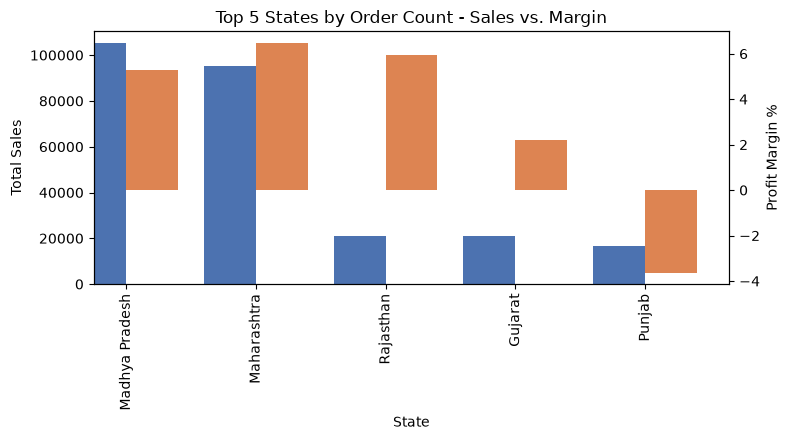

In [15]:
fig, ax1 = plt.subplots()
state_summary['total_sales'].plot(
    kind='bar', ax=ax1, color='#4C72B0', position=1, width=0.4,
)
ax1.set_ylabel('Total Sales')

ax2 = ax1.twinx()
state_summary['margin_pct'].plot(
    kind='bar', ax=ax2, color='#DD8452', position=0, width=0.4,
)
ax2.set_ylabel('Profit Margin %')

plt.title('Top 5 States by Order Count - Sales vs. Margin')
fig.tight_layout()
plt.show()

The top-5-by-orders list and the sales figures don't move together, so it's
worth checking margin across *all* states too, not just these five, and then
drilling into cities within the top 5 to see where the weak spots actually
are. (One more raw-data note: 3 orders are tagged City = Delhi but
State = Madhya Pradesh, so "Delhi" shows up in the city table below even
though Delhi isn't one of the top-5 states - that's a labeling slip in the
source file, not a computation issue, and at 3 orders it doesn't move any of
the conclusions.)

In [16]:
all_state_summary = df.groupby('State').agg(
    total_sales=('Amount', 'sum'),
    total_profit=('Profit', 'sum'),
)
all_state_summary['orders'] = orders['State'].value_counts()

sales, profit = all_state_summary['total_sales'], all_state_summary['total_profit']
all_state_summary['margin_pct'] = profit / sales * 100
all_state_summary.sort_values('margin_pct').head(6)

,total_sales,total_profit,orders,margin_pct
State,,,,
Tamil Nadu,6087,-2216,8,-36.41
Andhra Pradesh,13256,-496,15,-3.74
Punjab,16786,-609,25,-3.63
Bihar,12943,-321,16,-2.48
Jammu and Kashmir,10829,8,14,0.07
Nagaland,11903,148,15,1.24


In [17]:
city_rows = orders[orders['State'].isin(top5_states.index)]

city_summary = state_rows.groupby('City').agg(
    total_sales=('Amount', 'sum'),
    total_profit=('Profit', 'sum'),
)
city_summary['orders'] = city_rows['City'].value_counts()

sales, profit = city_summary['total_sales'], city_summary['total_profit']
city_summary['margin_pct'] = profit / sales * 100
city_summary.sort_values('orders', ascending=False)

,total_sales,total_profit,orders,margin_pct
City,,,,
Indore,79069,4159,76,5.26
Mumbai,61867,1637,68,2.65
Bhopal,23583,871,22,3.69
Pune,33481,4539,22,13.56
Jaipur,10076,-753,19,-7.47
Ahmedabad,14230,-880,17,-6.18
Chandigarh,12279,-1153,16,-9.39
Udaipur,11073,2010,13,18.15
Surat,6828,1345,10,19.70


### Findings - Part 3

Madhya Pradesh and Maharashtra dominate order volume (101 and 90 orders -
more than 3x the next closest state), and unsurprisingly they also produce
the most total sales and profit in absolute terms. But the real story in
this data is the 5th state:

- **Punjab is the standout problem among the top 5** - 25 orders, but a
  **-3.6% margin and -₹24 average profit per order**, the only one of the
  five actually losing money. It's driven almost entirely by
  **Chandigarh**, which is running at a **-9.4% margin** and accounts for
  16 of Punjab's 25 orders - Amritsar, the other city in the state, is
  healthy on its own (+12.1% margin), so this is a Chandigarh-specific issue
  rather than a state-wide one.
- **Gujarat is also weaker than it looks** - 27 orders but only a 2.2%
  margin, well behind Maharashtra (6.5%) and Madhya Pradesh (5.3%). Almost
  all of that comes down to **Ahmedabad** (-6.2% margin), even though
  **Surat** in the same state is doing well (+19.7%).
- **Rajasthan tells a similar story at the city level** - the state overall
  sits at a reasonable 5.9% margin, but that's an average of a
  strongly-negative Jaipur (-7.5%) and a strongly-positive Udaipur (+18.2%)
  more or less cancelling out.
- Zooming out past the top 5, **Punjab isn't even the worst state overall**
  - Tamil Nadu (-36.4%, though only 8 orders) and Andhra Pradesh (-3.7%)
  are both worse on margin. Low order counts mean these two won't move the
  company-wide numbers much on their own, but a -36% margin at any scale is
  unusual enough to be worth a root-cause look.

**Where I'd prioritize:** Punjab first - it's the only top-5-by-volume state
that's actually losing money, which means the fix (almost certainly
something specific to Chandigarh - pricing, discounting, or return rates)
has more leverage than a similar fix in a low-volume state would. Ahmedabad
and Jaipur are next, since they're negative-margin cities sitting inside
states with decent volume and a healthy twin city right next to them,
suggesting the problem is local execution rather than the whole region
being unviable. Tamil Nadu is the most extreme number on the sheet and
probably deserves a look too, even at low volume, since -36% is too large to
just be normal variance.

## Wrap-up

Across all three parts, the pattern is the same: the "total sales" number
and the "actually profitable" number disagree the most in a few specific
slices - Furniture (particularly Tables), and Chandigarh/Ahmedabad/Jaipur
within otherwise-solid states. None of these are volume problems - they're
margin problems - so the fix is more likely to be in pricing, discounting or
logistics for those specific slices rather than in driving more orders to
them.